# Fully Connected Autoencoder with SWaT Dataset 2020

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("SWaT_cleaned_data_2020.csv")

print(df.shape)
df.head()

(32402, 61)


,P206.Status,MV501.Status,P203.Status,MV302.Status,MV101.Status,P4_STATE,P101.Status,P404.Status,P402.Status,P204.Status,...,AIT504.Pv,DPIT301.Pv,LIT401.Pv,LIT301.Pv,P1_STATE,FIT502.Pv,P502.Status,MV201.Status,P302.Status,P6_STATE
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.479400,1008.27515,1.0,0.002562,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.556300,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.440900,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.653166,3.755042,830.979248,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.653166,3.755042,830.594700,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0


In [3]:
timestamps = pd.to_datetime(df['t_stamp'], errors='coerce')
df = df.drop(columns=['t_stamp'])

## Verificar valores faltantes

In [ ]:
df.isna().sum().sum()

np.int64(60)

In [5]:
df = df.fillna(method="ffill")
df.isna().sum().sum()

C:\Users\Juan\AppData\Local\Temp\ipykernel_30008\446086851.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


np.int64(0)

## Normalización

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(df)

data_scaled = pd.DataFrame(data_scaled, columns=df.columns)

## Crear ventanas temporales

Empezar con L = 60, stride = 5

In [9]:
def create_windows(data, window_size=60, stride=5):

    windows = []

    for i in range(0, len(data) - window_size, stride):
        window = data[i:i+window_size]
        windows.append(window)

    return np.array(windows)

In [10]:
windows = create_windows(data_scaled.values, window_size=60, stride=5)

print(windows.shape)

(6469, 60, 60)


## Aplanar ventanas para FC Autoencoder

In [11]:
n_windows, L, n_features = windows.shape

X = windows.reshape(n_windows, L * n_features)

print(X.shape)

(6469, 3600)


## Convertir a PyTorch

In [13]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_tensor = torch.tensor(X, dtype=torch.float32)

dataset = TensorDataset(X_tensor)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

## Implementación FC Autoencoder

In [14]:
import torch.nn as nn

class FCAutoencoder(nn.Module):

    def __init__(self, input_dim):

        super(FCAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)
        x_hat = self.decoder(z)

        return x_hat

In [15]:
input_dim = X.shape[1]

model = FCAutoencoder(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

## Definición de entramiento

In [16]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30

## Entrenamiento

In [17]:
for epoch in range(epochs):

    total_loss = 0

    for batch in loader:

        x = batch[0].to(device)

        optimizer.zero_grad()

        x_hat = model(x)

        loss = criterion(x_hat, x)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader)}")

Epoch 1/30, Loss: 0.25368875232251253
Epoch 2/30, Loss: 0.11114702362786322
Epoch 3/30, Loss: 0.08654306542274415
Epoch 4/30, Loss: 0.08085637070311635
Epoch 5/30, Loss: 0.07489247251228959
Epoch 6/30, Loss: 0.06895142541650463
Epoch 7/30, Loss: 0.06564568928168978
Epoch 8/30, Loss: 0.06324689899224277
Epoch 9/30, Loss: 0.06597376181561426
Epoch 10/30, Loss: 0.06162715181890948
Epoch 11/30, Loss: 0.06376932524875098
Epoch 12/30, Loss: 0.06019772525748932
Epoch 13/30, Loss: 0.06125436643795932
Epoch 14/30, Loss: 0.055664988490296344
Epoch 15/30, Loss: 0.0673986357892407
Epoch 16/30, Loss: 0.05825513519355845
Epoch 17/30, Loss: 0.055879421806072485
Epoch 18/30, Loss: 0.05700197240666432
Epoch 19/30, Loss: 0.05485974884975482
Epoch 20/30, Loss: 0.050366646108016666
Epoch 21/30, Loss: 0.0489584823349016
Epoch 22/30, Loss: 0.04381649360498961
Epoch 23/30, Loss: 0.04265910870961699
Epoch 24/30, Loss: 0.04446090741411728
Epoch 25/30, Loss: 0.04677852418949353
Epoch 26/30, Loss: 0.046603881621

## Error de reconstrucción

In [18]:
model.eval()

reconstruction_errors = []

with torch.no_grad():

    for batch in loader:

        x = batch[0].to(device)

        x_hat = model(x)

        error = torch.mean((x - x_hat)**2, dim=1)

        reconstruction_errors.extend(error.cpu().numpy())

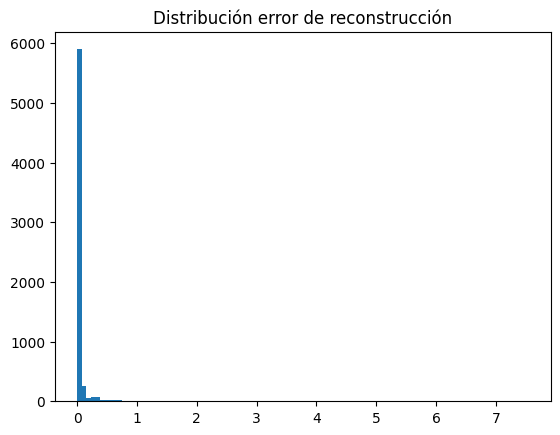

In [19]:
import matplotlib.pyplot as plt

plt.hist(reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción")
plt.show()

## Percentiles

In [20]:
np.percentile(reconstruction_errors, [90,95,97.5,99])

array([0.05595124, 0.14631709, 0.32801638, 0.61583233])